# SAAM Project 2026 — Portfolio Allocation with a Carbon Objective
**Group BR — North America + Europe — Scope 1 + Scope 2**

This notebook reproduces, end to end, every table and figure of the report.
It runs top to bottom with no manual intervention and only relative paths.

**Structure**
- Part I — standard allocation: value-weighted benchmark `P_vw` and global
  minimum-variance portfolio `P_mv`.
- Part II — carbon-aware allocation: `P_mv(0.5)`, `P_vw(0.5)` and the
  net-zero portfolio `P_vw(NZ)`.


## 0. Setup

In [1]:
import warnings

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = "data/"

YEARS = list(range(2013, 2024))   # allocation years: Dec 2013 ... Dec 2023
THETA = 0.10                      # net-zero annual decarbonisation rate
SUB = "Group BR  |  North America + Europe  |  Scope 1+2"
COL = {"vw": "#1f3a93", "mv": "#c0392b", "mv05": "#e67e22",
       "vw05": "#16a085", "nz": "#27ae60"}
LABEL = {"vw": "P_vw", "mv": "P_mv", "mv05": "P_mv(0.5)",
         "vw05": "P_vw(0.5)", "nz": "P_vw(NZ)"}

## 1. Data loading and reshaping

All Data files are reshaped. Monthly series become
`(date x ISIN)` matrices, annual series become `(ISIN x year)` matrices.
Scope 1 and Scope 2 emissions are summed and
emissions and revenues are forward-filled across years.

In [2]:
static = pd.read_excel(DATA_DIR + "Static_2025.xlsx").drop_duplicates("ISIN")
name_map = static.set_index("ISIN")["NAME"]
country_map = static.set_index("ISIN")["Country"]
our_isins = static[static["Region"].isin(["AMER", "EUR"])]["ISIN"].tolist()


def load_and_reshape(filename, isins):
    '''Monthly Excel file -> (date x ISIN) numeric matrix.'''
    df = pd.read_excel(DATA_DIR + filename).drop_duplicates("ISIN")
    df = df[df["ISIN"].isin(isins)]
    date_cols = [c for c in df.columns if c not in ("NAME", "ISIN")]
    matrix = df.set_index("ISIN")[date_cols].T
    matrix.index = pd.to_datetime(matrix.index)
    return matrix.apply(pd.to_numeric, errors="coerce")


def load_yearly(filename, isins):
    '''Annual Excel file -> (ISIN x year) numeric matrix.'''
    df = pd.read_excel(DATA_DIR + filename).drop_duplicates("ISIN")
    df = df[df["ISIN"].isin(isins)]
    year_cols = [c for c in df.columns if isinstance(c, (int, float))]
    return df.set_index("ISIN")[year_cols].apply(pd.to_numeric, errors="coerce")


prices = load_and_reshape("DS_RI_T_USD_M_2025.xlsx", our_isins)
mktcap = load_and_reshape("DS_MV_T_USD_M_2025.xlsx", our_isins)

co2 = (load_yearly("DS_CO2_SCOPE_1_Y_2025.xlsx", our_isins)
       .add(load_yearly("DS_CO2_SCOPE_2_Y_2025.xlsx", our_isins), fill_value=0)
       .ffill(axis=1))
revenue = load_yearly("DS_REV_Y_2025.xlsx", our_isins).ffill(axis=1)

rf = pd.read_excel(DATA_DIR + "Risk_Free_Rate_2025.xlsx")
rf.columns = ["Date", "RF"]
rf["Date"] = pd.to_datetime(rf["Date"].astype(str), format="%Y%m") \
    + pd.offsets.MonthEnd(0)
rf = rf.set_index("Date")
rf["RF"] = rf["RF"] / 100 / 12     # annualised % -> monthly decimal

print(f"{len(our_isins)} AMER+EUR firms | {prices.shape[0]} monthly dates")

1302 AMER+EUR firms | 314 monthly dates


## 2. Data cleaning and returns

Cleaning rules: drop fully-empty ISINs, treat any
total-return-index value below 0.5 as missing, compute simple monthly returns,
and book a −100% return in the month after a firm's last valid price.

In [3]:
prices = prices.dropna(axis=1, how="all")          # drop unmatched ISINs
mktcap = mktcap.reindex(columns=prices.columns)
prices = prices.where(prices >= 0.5)               # low prices -> missing
returns = prices.pct_change().iloc[1:]             # simple monthly returns

n_delist = 0
for col in returns.columns:
    last_valid = prices[col].last_valid_index()
    if last_valid is not None and last_valid < prices.index[-1]:
        nxt = prices.index[prices.index.get_loc(last_valid) + 1]
        if nxt in returns.index:
            returns.loc[nxt, col] = -1.0
            n_delist += 1

print(f"Returns: {returns.shape[0]} months x {returns.shape[1]} firms "
      f"| {n_delist} delistings booked at -100%")

Returns: 313 months x 1302 firms | 112 delistings booked at -100%


## 3. Investment set

At the end of each year `Y` the investment set keeps firms that: belong to
the assigned region, have at least 36 monthly returns over the 10-year window,
show at most 50% zero returns, have a valid year-end price and market
cap, have carbon and revenue data so the carbon footprint and intensity
are defined for **every** firm. --> The same set is used by all five portfolios.

In [4]:
def dec(year, index):
    '''December year-end date of `year` present in a DatetimeIndex.'''
    d = index[(index.month == 12) & (index.year == year)]
    return d[0] if len(d) else None


_elig_cache = {}


def get_eligible(year):
    '''Investment set at the end of year Y (identical for all portfolios).'''
    if year in _elig_cache:
        return _elig_cache[year]
    win = returns.loc[dec(year - 10, returns.index):dec(year, returns.index)]
    valid = win.notna().sum()
    zero_pct = (win == 0).sum() / valid.replace(0, np.nan)
    d_year = dec(year, prices.index)
    has_price = prices.loc[d_year].notna()
    cap = mktcap.loc[d_year]
    has_cap = cap.notna() & (cap > 0)
    has_co2 = pd.Series({i: (co2.loc[i, :year].notna().any()
                             if i in co2.index else False)
                         for i in win.columns})
    has_rev = pd.Series({i: (i in revenue.index and year in revenue.columns
                             and pd.notna(revenue.loc[i, year]))
                         for i in win.columns})
    mask = (valid >= 36) & (zero_pct <= 0.5) & has_price & has_cap \
        & has_co2 & has_rev
    _elig_cache[year] = mask[mask].index.tolist()
    return _elig_cache[year]


def year_data(year):
    '''Everything needed for the allocation decided at the end of year Y.'''
    elig = get_eligible(year)
    win = returns.loc[dec(year - 10, returns.index):dec(year, returns.index)]
    cov = win[elig].fillna(0.0).cov().values
    cov = cov + np.eye(len(elig)) * 1e-8           # regularise -> pos. definite
    d_year = dec(year, prices.index)
    cap = mktcap.loc[d_year, elig].astype(float)   # year-end cap (USD million)
    emis = co2.loc[elig, year].astype(float)       # Scope 1+2 (tonnes CO2)
    rev_m = revenue.loc[elig, year].astype(float) / 1000.0   # -> USD million
    return {"year": year, "elig": elig, "cov": cov, "cap": cap, "emis": emis,
            "ci": emis / rev_m,        # carbon intensity   (tCO2 / $M revenue)
            "carb": emis / cap,        # carbon per cap     (tCO2 / $M invested)
            "w_vw": cap / cap.sum()}   # value-weighted benchmark weights


yd = {Y: year_data(Y) for Y in YEARS}
pd.Series({Y: len(yd[Y]["elig"]) for Y in YEARS}, name="Investment set size")

2013     835
2014     859
2015     891
2016     914
2017     946
2018    1003
2019    1093
2020    1138
2021    1168
2022    1166
2023    1150
Name: Investment set size, dtype: int64

## 4. Optimisation building blocks

Every portfolio is a long-only, fully-invested quadratic program. The carbon
footprint is linear in the weights --> $CF_Y(\alpha)=\sum_i \alpha_i E_{i,Y}/Cap_{i,Y}$,
So a footprint ceiling is a single linear constraint. Problems are solved
with CLARABEL (OSQP as fallback).

In [5]:
def _solve(objective, n, extra_cons):
    '''Solve a long-only QP; return cleaned weights and solver status.'''
    w = cp.Variable(n)
    cons = [cp.sum(w) == 1, w >= 0] + extra_cons(w)
    prob = cp.Problem(cp.Minimize(objective(w)), cons)
    for solver in (cp.CLARABEL, cp.OSQP):
        try:
            if solver == cp.OSQP:
                prob.solve(solver=solver, max_iter=60000,
                           eps_abs=1e-9, eps_rel=1e-9, polish=True)
            else:
                prob.solve(solver=solver)
            if w.value is not None and prob.status in (
                    "optimal", "optimal_inaccurate"):
                val = np.clip(np.asarray(w.value), 0, None)
                return val / val.sum(), prob.status
        except Exception:
            continue
    return None, "failed"


def min_variance(d, cf_limit=None):
    '''Long-only minimum-variance weights, optional carbon-footprint cap.'''
    P, carb = cp.psd_wrap(d["cov"]), d["carb"].values
    extra = (lambda w: [carb @ w <= cf_limit]) if cf_limit is not None \
        else (lambda w: [])
    w, st = _solve(lambda w: cp.quad_form(w, P), len(d["elig"]), extra)
    return pd.Series(w, index=d["elig"]), st


def min_tracking_error(d, cf_limit=None):
    '''Long-only tracking-error minimisation vs the VW benchmark.'''
    P, wvw, carb = cp.psd_wrap(d["cov"]), d["w_vw"].values, d["carb"].values
    extra = (lambda w: [carb @ w <= cf_limit]) if cf_limit is not None \
        else (lambda w: [])
    w, st = _solve(lambda w: cp.quad_form(w - wvw, P), len(d["elig"]), extra)
    return pd.Series(w, index=d["elig"]), st


def cf(d, w):      # portfolio carbon footprint  (tCO2 / $M invested)
    return float(d["carb"].values @ np.asarray(w))


def waci(d, w):    # weighted-average carbon intensity (tCO2 / $M revenue)
    return float(d["ci"].values @ np.asarray(w))

## 5. Part I — Standard portfolio allocation

`P_mv` minimises portfolio variance each December for the next year, long-only
and fully invested. `P_vw` is the value-weighted benchmark, rebalanced monthly
on the previous month's market caps. Weights drift with realised returns
between annual rebalancing dates.

In [6]:
def backtest_optimized(weights_by_year):
    '''Monthly returns of an annually-rebalanced portfolio with weight drift.'''
    rows = []
    for Y, w0 in weights_by_year.items():
        elig = list(w0.index)
        future = returns.loc[returns.index.year == Y + 1, elig].fillna(0.0)
        w = w0.copy()
        for date, row in future.iterrows():
            rows.append({"Date": date, "Return": float((w * row).sum())})
            w = w * (1 + row)
            w = w / w.sum()
    return pd.DataFrame(rows).set_index("Date")["Return"]


def backtest_vw():
    '''Value-weighted benchmark: monthly rebalanced on previous-month caps.'''
    rows = []
    for Y in YEARS:
        elig = get_eligible(Y)
        future = returns.loc[returns.index.year == Y + 1, elig].fillna(0.0)
        for date in future.index:
            prev = mktcap.index[mktcap.index.get_loc(date) - 1]
            w = (mktcap.loc[prev, elig].fillna(0.0)).pipe(lambda c: c / c.sum())
            rows.append({"Date": date,
                         "Return": float((w * future.loc[date]).sum())})
    return pd.DataFrame(rows).set_index("Date")["Return"]


w_mv = {}
for Y in YEARS:
    w_mv[Y], _ = min_variance(yd[Y])

ret_series = {"vw": backtest_vw(), "mv": backtest_optimized(w_mv)}
print(f"Backtest: {len(ret_series['vw'])} monthly returns "
      f"({ret_series['vw'].index[0]:%Y-%m} to {ret_series['vw'].index[-1]:%Y-%m})")

Backtest: 132 monthly returns (2014-01 to 2024-12)


In [7]:
def summary(r):
    '''Annualised performance statistics for a monthly return series.'''
    excess = r - rf["RF"].reindex(r.index, method="nearest")
    T = len(r)
    return {"Ann. avg return": r.mean() * 12,
            "Ann. volatility": r.std() * np.sqrt(12),
            "Ann. cum return": (1 + r).prod() ** (12 / T) - 1,
            "Sharpe ratio": excess.mean() / excess.std() * np.sqrt(12),
            "Min": r.min(), "Max": r.max(),
            "Cumulative return": (1 + r).prod() - 1}


stats = {p: summary(r) for p, r in ret_series.items()}
pd.DataFrame({LABEL[p]: stats[p] for p in ("vw", "mv")}).round(4)

,P_vw,P_mv
Ann. avg return,0.1062,0.0596
Ann. volatility,0.1462,0.1404
Ann. cum return,0.0999,0.0507
Sharpe ratio,0.7178,0.4150
Min,-0.1313,-0.2020
Max,0.1288,0.1225
Cumulative return,1.8498,0.7226


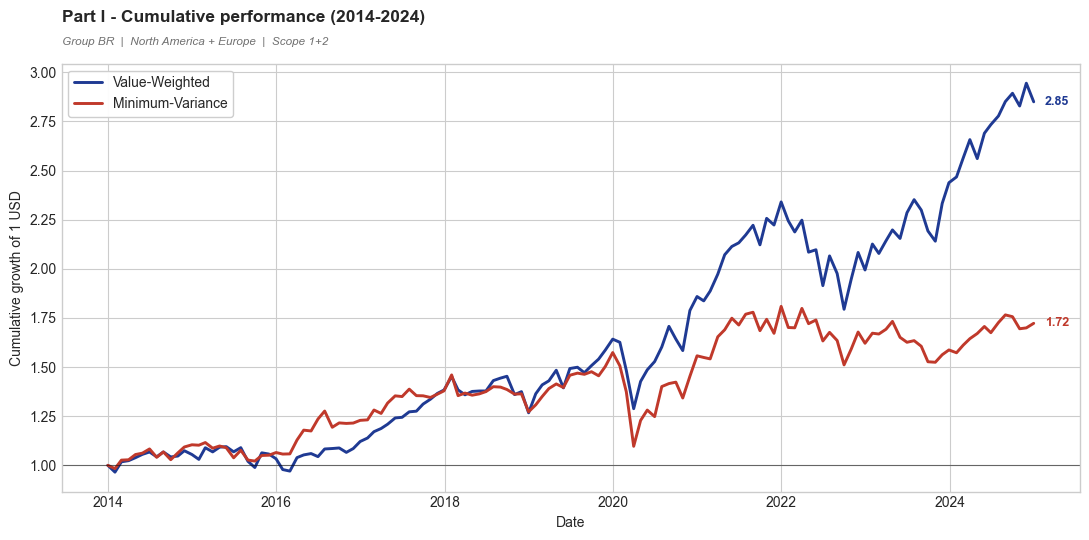

In [8]:
def growth_index(r):
    '''Growth of 1 USD, anchored at 1.0 the month before the first return.'''
    cum = (1 + r).cumprod()
    start = r.index[0] - pd.offsets.MonthEnd(1)
    return pd.concat([pd.Series([1.0], index=[start]), cum])


def _titles(ax, title):
    ax.set_title(title, fontsize=12.5, fontweight="bold", loc="left", pad=30)
    ax.text(0.0, 1.045, SUB, transform=ax.transAxes, fontsize=8.5,
            alpha=0.65, style="italic")


def _stagger(values, gap):
    order = np.argsort(values)
    pos = np.array(values, dtype=float)
    for k in range(1, len(order)):
        i, j = order[k], order[k - 1]
        if pos[i] - pos[j] < gap:
            pos[i] = pos[j] + gap
    return pos


def fig_cumulative(keys, labels, title):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ends = []
    for key, lab in zip(keys, labels):
        g = growth_index(ret_series[key])
        ax.plot(g.index, g.values, color=COL[key], linewidth=2.1, label=lab)
        ends.append(g.iloc[-1])
    last_x = growth_index(ret_series[keys[0]]).index[-1]
    for key, ev in zip(keys, ends):
        ax.annotate(f"{ev:.2f}", xy=(last_x, ev), xytext=(8, 0),
                    textcoords="offset points", color=COL[key],
                    fontweight="bold", va="center", fontsize=9,
                    annotation_clip=False)
    ax.axhline(1.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_ylabel("Cumulative growth of 1 USD")
    ax.set_xlabel("Date")
    _titles(ax, title)
    ax.legend(loc="upper left", frameon=True, framealpha=0.95)
    plt.tight_layout()
    plt.show()


fig_cumulative(["vw", "mv"], ["Value-Weighted", "Minimum-Variance"],
               "Part I - Cumulative performance (2014-2024)")

## 6. Part II §3.1 — Carbon emissions of the base portfolios

Carbon intensity is $CI_{i,Y}=E_{i,Y}/(Rev_{i,Y}/1000)$ (revenue converted from
thousands to millions of USD). For a portfolio with weights $\alpha$,
$$WACI_Y=\sum_i\alpha_{i,Y}\,CI_{i,Y},\qquad
  CF_Y=\sum_i\alpha_{i,Y}\,E_{i,Y}/Cap_{i,Y}.$$
For the value-weighted portfolio this collapses to
$CF_Y=\sum_iE_{i,Y}/\sum_iCap_{i,Y}$.

In [9]:
carbon = {p: {"cf": {}, "waci": {}} for p in
          ("vw", "mv", "mv05", "vw05", "nz")}
for Y in YEARS:
    d = yd[Y]
    for tag, w in (("vw", d["w_vw"]), ("mv", w_mv[Y])):
        carbon[tag]["cf"][Y] = cf(d, w)
        carbon[tag]["waci"][Y] = waci(d, w)

cf_vw_2013 = carbon["vw"]["cf"][2013]      # net-zero baseline
carbon_tbl = pd.DataFrame({
    "P_vw CF": carbon["vw"]["cf"], "P_mv CF": carbon["mv"]["cf"],
    "P_vw WACI": carbon["vw"]["waci"], "P_mv WACI": carbon["mv"]["waci"]})
carbon_tbl.round(1)

,P_vw CF,P_mv CF,P_vw WACI,P_mv WACI
2013,167.8,471.8,205.4,936.5
2014,167.0,1291.9,215.1,893.1
2015,170.5,1688.8,199.1,782.7
2016,155.7,169.5,233.4,174.5
2017,126.4,476.0,225.1,519.4
2018,136.2,427.0,204.0,663.5
2019,99.6,1248.7,180.9,995.5
2020,80.4,440.0,148.7,549.9
2021,66.1,92.7,155.0,320.9
2022,77.7,105.5,147.4,220.8


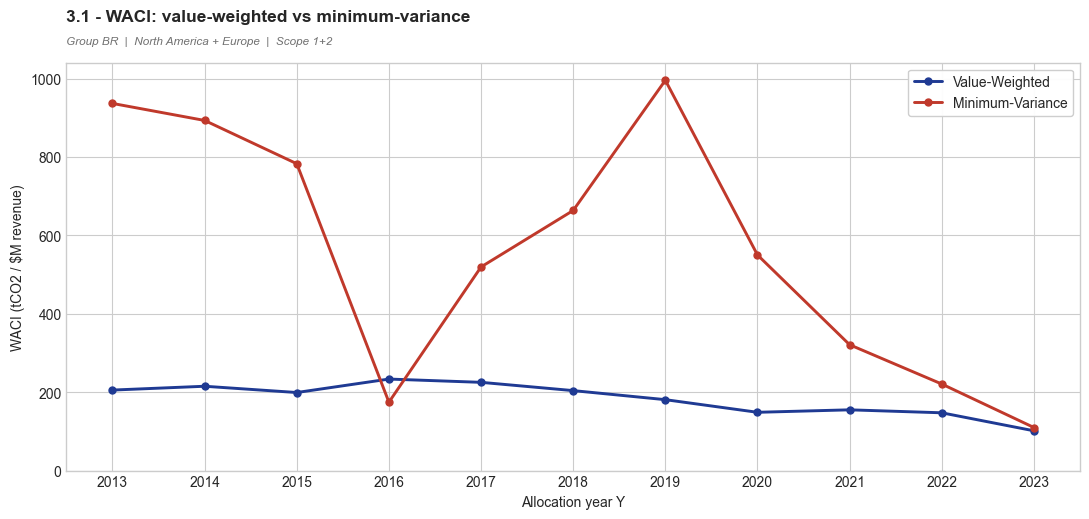

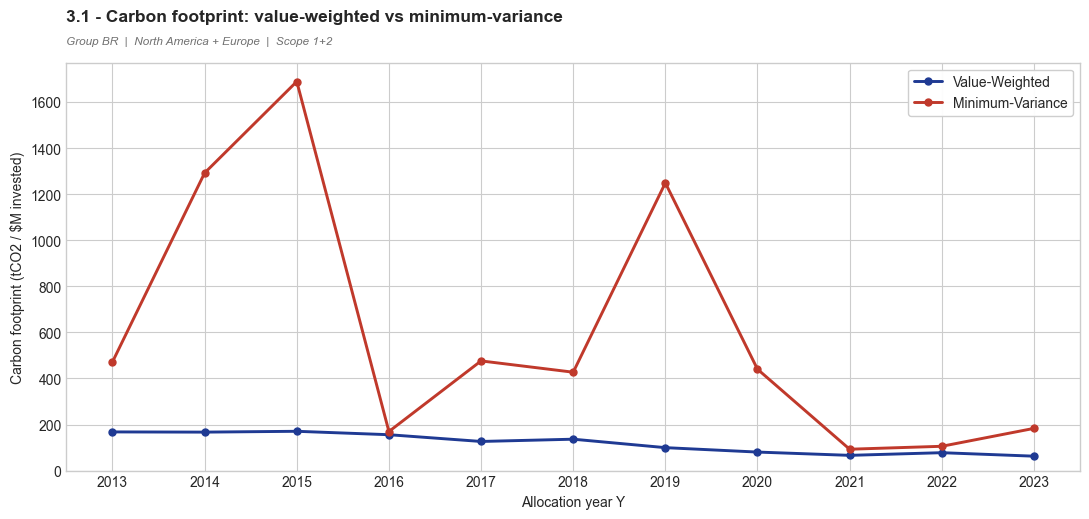

In [10]:
def fig_carbon(metric, keys, labels, title, ylabel, target=None):
    fig, ax = plt.subplots(figsize=(11, 5.3))
    for key, lab in zip(keys, labels):
        ax.plot(YEARS, [carbon[key][metric][Y] for Y in YEARS], "o-",
                color=COL[key], linewidth=2.1, markersize=5, label=lab)
    if target is not None:
        ax.plot(YEARS, target, "--", color="black", linewidth=1.5, alpha=0.7,
                label="Net-zero target ceiling")
    ax.set_xlabel("Allocation year Y")
    ax.set_ylabel(ylabel)
    ax.set_xticks(YEARS)
    ax.set_ylim(bottom=0)
    _titles(ax, title)
    ax.legend(loc="best", frameon=True, framealpha=0.95)
    plt.tight_layout()
    plt.show()


fig_carbon("waci", ["vw", "mv"], ["Value-Weighted", "Minimum-Variance"],
           "3.1 - WACI: value-weighted vs minimum-variance",
           "WACI (tCO2 / $M revenue)")
fig_carbon("cf", ["vw", "mv"], ["Value-Weighted", "Minimum-Variance"],
           "3.1 - Carbon footprint: value-weighted vs minimum-variance",
           "Carbon footprint (tCO2 / $M invested)")

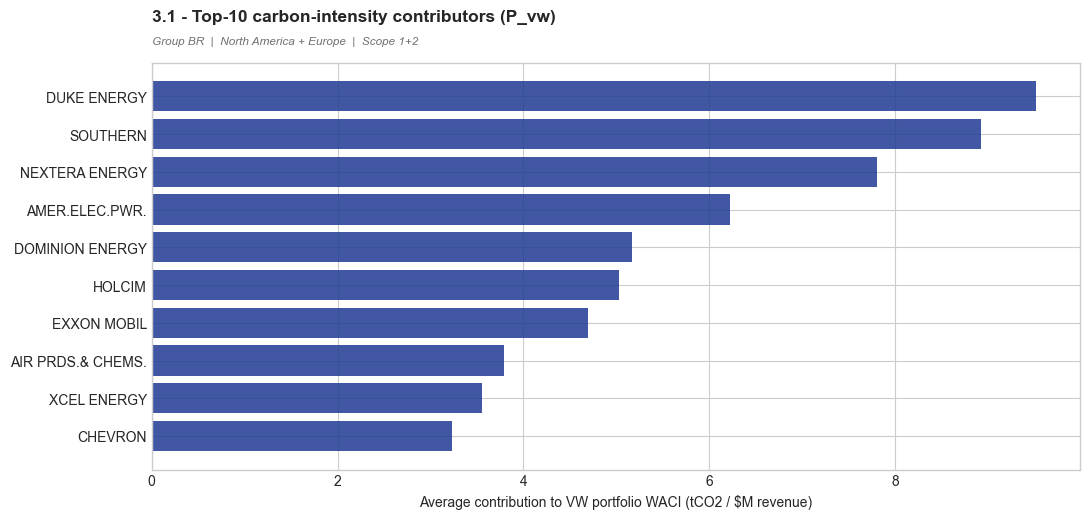

,ISIN,Name,Country,Avg WACI contribution,CI 2023,VW weight 2023 %
0,US26441C2044,DUKE ENERGY,US,9.51,2552.62,0.16
1,US8425871071,SOUTHERN,US,8.92,2717.67,0.16
2,US65339F1012,NEXTERA ENERGY,US,7.80,2018.25,0.27
3,US0255371017,AMER.ELEC.PWR.,US,6.22,2269.11,0.09
4,US25746U1097,DOMINION ENERGY,US,5.17,1744.95,0.08
5,CH0012214059,HOLCIM,CH,5.03,2430.88,0.10
6,US30231G1022,EXXON MOBIL,US,4.69,250.83,0.85
7,US0091581068,AIR PRDS.& CHEMS.,US,3.79,2143.01,0.13
8,US98389B1008,XCEL ENERGY,US,3.55,2383.41,0.07
9,US1667641005,CHEVRON,US,3.23,229.09,0.60


In [11]:
# Top-10 contributors to the value-weighted portfolio's carbon intensity
contrib = {}
for Y in YEARS:
    d = yd[Y]
    for isin, val in (d["w_vw"] * d["ci"]).items():
        contrib[isin] = contrib.get(isin, 0.0) + val / len(YEARS)

top10 = sorted(contrib.items(), key=lambda kv: kv[1], reverse=True)[:10]
last = yd[2023]
top10_rows = [{"ISIN": i, "Name": str(name_map.get(i, "")),
               "Country": str(country_map.get(i, "")),
               "Avg WACI contribution": c,
               "CI 2023": float(last["ci"].get(i, np.nan)),
               "VW weight 2023 %": float(last["w_vw"].get(i, np.nan)) * 100}
              for i, c in top10]
top10_df = pd.DataFrame(top10_rows)

fig, ax = plt.subplots(figsize=(11, 5.3))
ax.barh([r["Name"][:34] for r in top10_rows[::-1]],
        [r["Avg WACI contribution"] for r in top10_rows[::-1]],
        color=COL["vw"], alpha=0.85)
ax.set_xlabel("Average contribution to VW portfolio WACI (tCO2 / $M revenue)")
_titles(ax, "3.1 - Top-10 carbon-intensity contributors (P_vw)")
plt.tight_layout()
plt.show()
top10_df.round(2)

## 7. Part II §3.2 — Minimum-variance with a 50% footprint cut: `P_mv(0.5)`

Same minimum-variance program as Part I, plus the linear constraint
$CF_Y(\alpha)\le 0.5\,CF_Y(P^{(mv)}_{oos})$.

In [12]:
w_mv05, feas_mv05 = {}, {}
for Y in YEARS:
    d = yd[Y]
    target = 0.5 * carbon["mv"]["cf"][Y]
    min_cf = float(d["carb"].min())            # lowest reachable long-only CF
    feas_mv05[Y] = target >= min_cf
    w_mv05[Y], _ = min_variance(d, cf_limit=max(target, min_cf * 1.0001))
    carbon["mv05"]["cf"][Y] = cf(d, w_mv05[Y])
    carbon["mv05"]["waci"][Y] = waci(d, w_mv05[Y])

ret_series["mv05"] = backtest_optimized(w_mv05)
stats["mv05"] = summary(ret_series["mv05"])
print("All 50% targets feasible:", all(feas_mv05.values()))
pd.DataFrame({LABEL[p]: stats[p] for p in ("mv", "mv05")}).round(4)

All 50% targets feasible: True


,P_mv,P_mv(0.5)
Ann. avg return,0.0596,0.0607
Ann. volatility,0.1404,0.1303
Ann. cum return,0.0507,0.0534
Sharpe ratio,0.4150,0.4562
Min,-0.2020,-0.1776
Max,0.1225,0.1271
Cumulative return,0.7226,0.7725


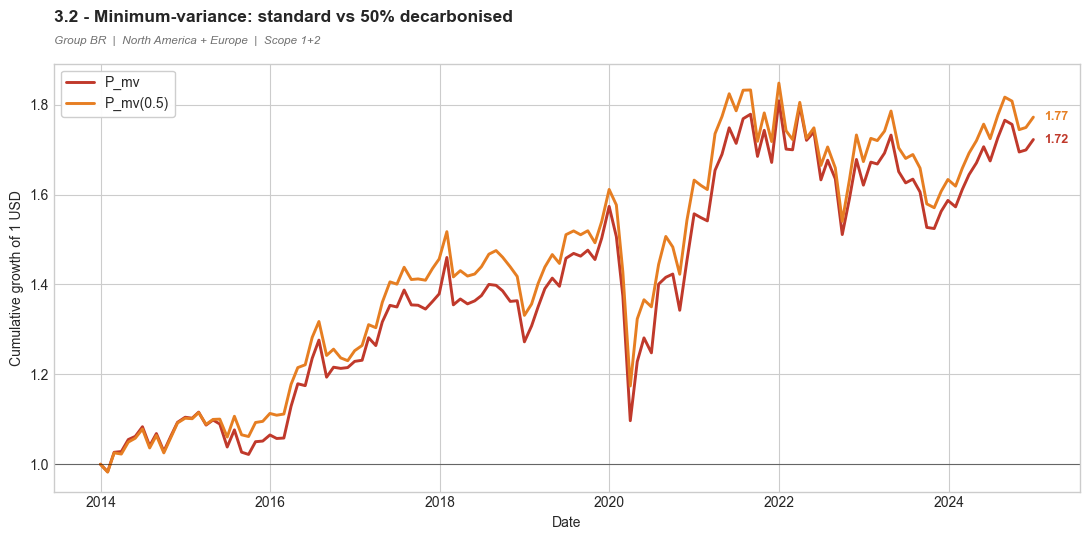

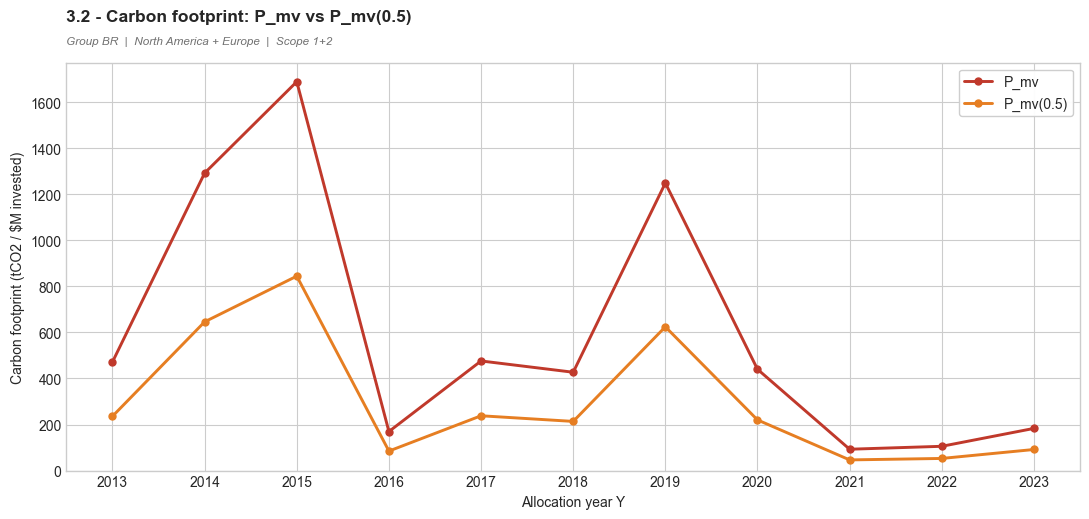

In [13]:
fig_cumulative(["mv", "mv05"], ["P_mv", "P_mv(0.5)"],
               "3.2 - Minimum-variance: standard vs 50% decarbonised")
fig_carbon("cf", ["mv", "mv05"], ["P_mv", "P_mv(0.5)"],
           "3.2 - Carbon footprint: P_mv vs P_mv(0.5)",
           "Carbon footprint (tCO2 / $M invested)")

## 8. Part II §3.3 — Tracking-error minimisation with a 50% cut: `P_vw(0.5)`

The "otherwise passive" investor stays as close as possible to the benchmark.
We minimise $(\alpha-\alpha^{vw})'\Sigma_Y(\alpha-\alpha^{vw})$ subject to
$CF_Y(\alpha)\le 0.5\,CF_Y(P^{(vw)})$, long-only and fully invested.

In [14]:
w_vw05, feas_vw05 = {}, {}
for Y in YEARS:
    d = yd[Y]
    target = 0.5 * carbon["vw"]["cf"][Y]
    min_cf = float(d["carb"].min())
    feas_vw05[Y] = target >= min_cf
    w_vw05[Y], _ = min_tracking_error(d, cf_limit=max(target, min_cf * 1.0001))
    carbon["vw05"]["cf"][Y] = cf(d, w_vw05[Y])
    carbon["vw05"]["waci"][Y] = waci(d, w_vw05[Y])

ret_series["vw05"] = backtest_optimized(w_vw05)
stats["vw05"] = summary(ret_series["vw05"])
print("All 50% targets feasible:", all(feas_vw05.values()))
pd.DataFrame({LABEL[p]: stats[p] for p in ("vw", "vw05")}).round(4)

All 50% targets feasible: True


,P_vw,P_vw(0.5)
Ann. avg return,0.1062,0.1016
Ann. volatility,0.1462,0.1463
Ann. cum return,0.0999,0.0948
Sharpe ratio,0.7178,0.6856
Min,-0.1313,-0.1418
Max,0.1288,0.1291
Cumulative return,1.8498,1.7074


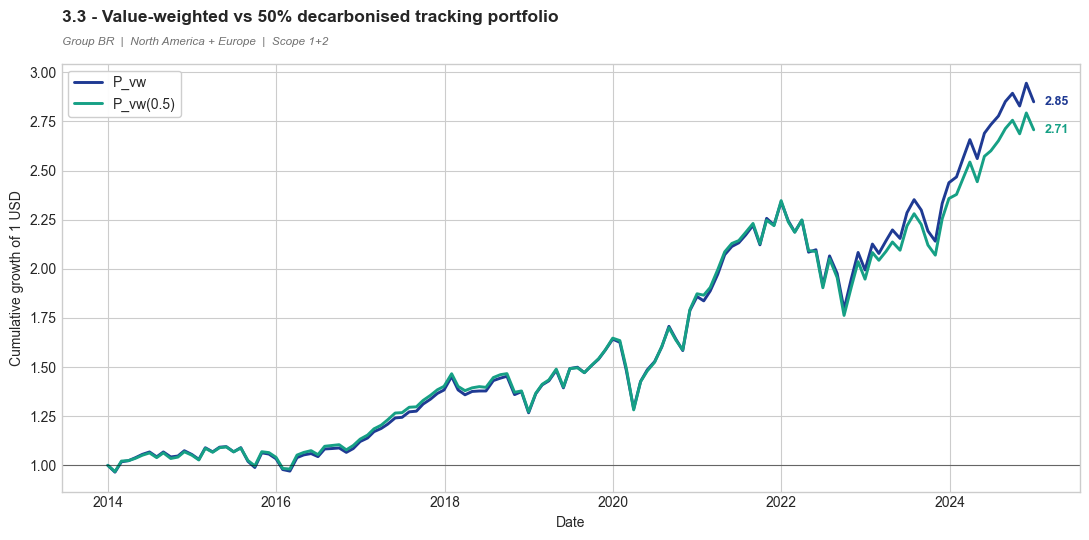

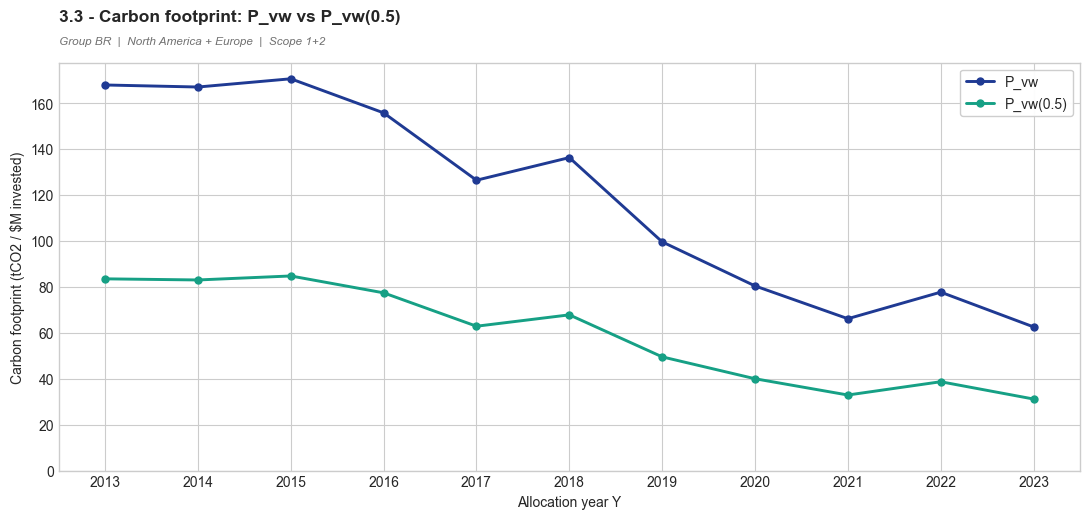

In [15]:
fig_cumulative(["vw", "vw05"], ["P_vw", "P_vw(0.5)"],
               "3.3 - Value-weighted vs 50% decarbonised tracking portfolio")
fig_carbon("cf", ["vw", "vw05"], ["P_vw", "P_vw(0.5)"],
           "3.3 - Carbon footprint: P_vw vs P_vw(0.5)",
           "Carbon footprint (tCO2 / $M invested)")

## 9. Part II §4 — Net-zero portfolio `P_vw(NZ)`

Same tracking-error program, but the footprint ceiling tightens by
$\theta=10\%$ every year relative to the 2013 value-weighted footprint:
$CF_Y(\alpha)\le(1-\theta)^{\,Y-Y_0+1}\,CF_{Y_0}(P^{(vw)})$ with $Y_0=2013$.

In [16]:
w_nz, feas_nz, nz_target = {}, {}, []
for Y in YEARS:
    d = yd[Y]
    target = (1 - THETA) ** (Y - 2013 + 1) * cf_vw_2013
    nz_target.append(target)
    min_cf = float(d["carb"].min())
    feas_nz[Y] = target >= min_cf
    w_nz[Y], _ = min_tracking_error(d, cf_limit=max(target, min_cf * 1.0001))
    carbon["nz"]["cf"][Y] = cf(d, w_nz[Y])
    carbon["nz"]["waci"][Y] = waci(d, w_nz[Y])

ret_series["nz"] = backtest_optimized(w_nz)
stats["nz"] = summary(ret_series["nz"])
print("All net-zero targets feasible:", all(feas_nz.values()))
pd.DataFrame({LABEL[p]: stats[p] for p in ("vw", "vw05", "nz")}).round(4)

All net-zero targets feasible: True


,P_vw,P_vw(0.5),P_vw(NZ)
Ann. avg return,0.1062,0.1016,0.1023
Ann. volatility,0.1462,0.1463,0.1464
Ann. cum return,0.0999,0.0948,0.0956
Sharpe ratio,0.7178,0.6856,0.6902
Min,-0.1313,-0.1418,-0.1419
Max,0.1288,0.1291,0.1290
Cumulative return,1.8498,1.7074,1.7290


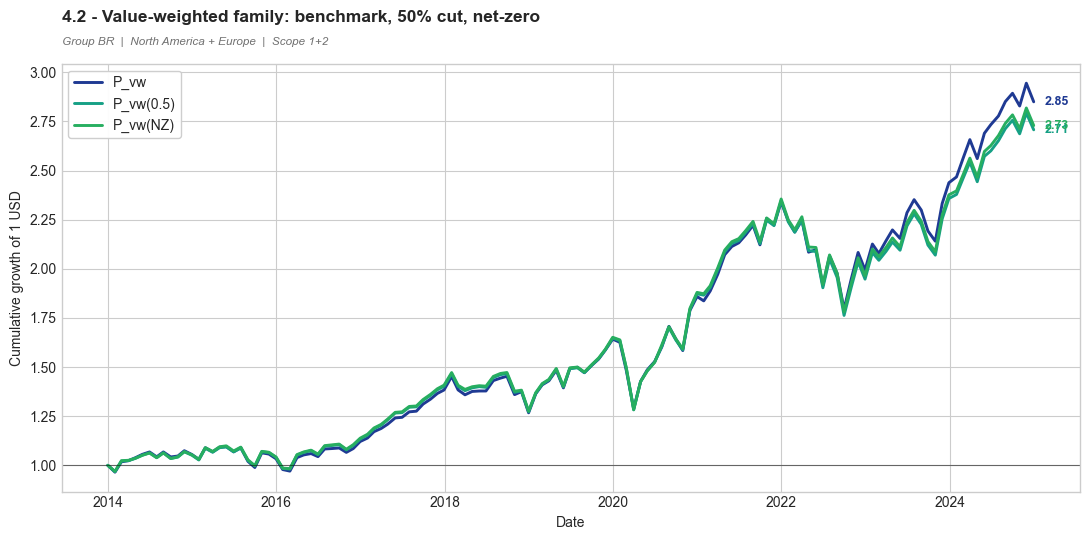

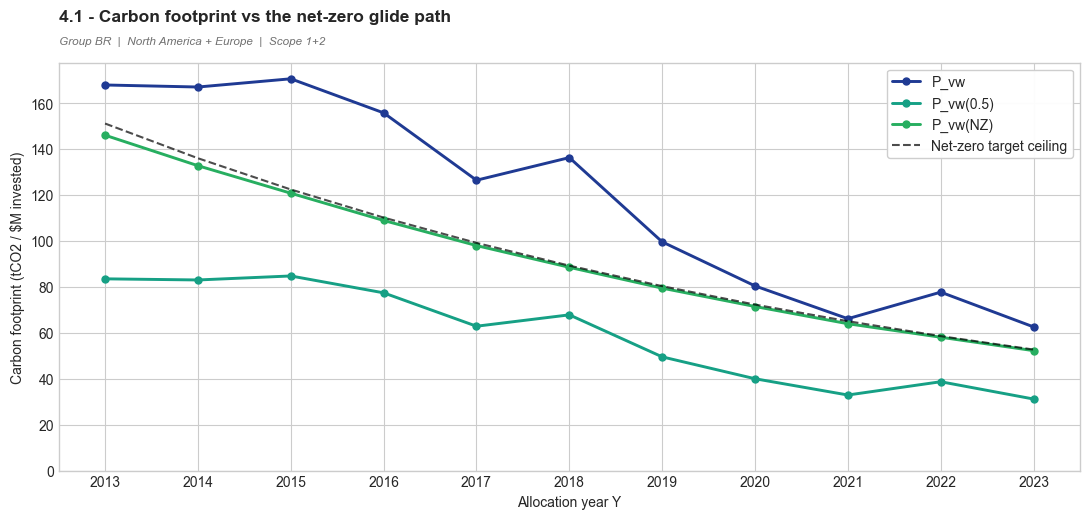

In [17]:
fig_cumulative(["vw", "vw05", "nz"], ["P_vw", "P_vw(0.5)", "P_vw(NZ)"],
               "4.2 - Value-weighted family: benchmark, 50% cut, net-zero")
fig_carbon("cf", ["vw", "vw05", "nz"], ["P_vw", "P_vw(0.5)", "P_vw(NZ)"],
           "4.1 - Carbon footprint vs the net-zero glide path",
           "Carbon footprint (tCO2 / $M invested)",
           target=nz_target)

## 10. Consolidated results

Performance and carbon metrics for all five portfolios, plus annualised
ex-post tracking error against the value-weighted benchmark.

In [18]:
def tracking_error(p, bench="vw"):
    return (ret_series[p] - ret_series[bench]).std() * np.sqrt(12)


perf = pd.DataFrame({LABEL[p]: stats[p] for p in
                     ("vw", "mv", "mv05", "vw05", "nz")})
perf.loc["Ann. tracking error"] = [np.nan] + [
    tracking_error(p) for p in ("mv", "mv05", "vw05", "nz")]
perf.round(4)

,P_vw,P_mv,P_mv(0.5),P_vw(0.5),P_vw(NZ)
Ann. avg return,0.1062,0.0596,0.0607,0.1016,0.1023
Ann. volatility,0.1462,0.1404,0.1303,0.1463,0.1464
Ann. cum return,0.0999,0.0507,0.0534,0.0948,0.0956
Sharpe ratio,0.7178,0.4150,0.4562,0.6856,0.6902
Min,-0.1313,-0.2020,-0.1776,-0.1418,-0.1419
Max,0.1288,0.1225,0.1271,0.1291,0.1290
Cumulative return,1.8498,0.7226,0.7725,1.7074,1.7290
Ann. tracking error,NaN,0.0966,0.0884,0.0109,0.0113


In [19]:
carbon_avg = pd.DataFrame({
    "Avg CF (tCO2/$M)": {LABEL[p]: np.mean(list(carbon[p]["cf"].values()))
                         for p in carbon},
    "Avg WACI (tCO2/$M rev)": {LABEL[p]: np.mean(list(carbon[p]["waci"].values()))
                               for p in carbon}})
carbon_avg["CF vs P_vw"] = (carbon_avg["Avg CF (tCO2/$M)"]
                            / carbon_avg.loc["P_vw", "Avg CF (tCO2/$M)"] - 1)
carbon_avg.round(3)

,Avg CF (tCO2/$M),Avg WACI (tCO2/$M rev),CF vs P_vw
P_vw,119.085,183.224,0.000
P_mv,599.558,560.606,4.035
P_mv(0.5),299.779,255.575,1.517
P_vw(0.5),59.212,90.720,-0.503
P_vw(NZ),92.704,130.268,-0.222


In [20]:
# Concentration: effective number of names  N_eff = 1 / sum(w^2)
def eff_n(w):
    w = np.asarray(w)
    return 1.0 / np.sum(w ** 2)


concentration = pd.DataFrame({
    "Avg effective N": {
        "P_vw": np.mean([eff_n(yd[Y]["w_vw"]) for Y in YEARS]),
        "P_mv": np.mean([eff_n(w_mv[Y]) for Y in YEARS]),
        "P_mv(0.5)": np.mean([eff_n(w_mv05[Y]) for Y in YEARS]),
        "P_vw(0.5)": np.mean([eff_n(w_vw05[Y]) for Y in YEARS]),
        "P_vw(NZ)": np.mean([eff_n(w_nz[Y]) for Y in YEARS])}})
concentration.round(1)

,Avg effective N
P_vw,158.8
P_mv,17.3
P_mv(0.5),17.6
P_vw(0.5),157.8
P_vw(NZ),161.4
